# Vibronic coupling in tetracene dimers
## General post-processing / prototyping notebook
### Can be done locally:


1. Boys localisation and partial diagonalisation (requires calc.chk)
    - reconstruct Fock matrix (takes some time)
    - localize frontier orbitals
    - visualize frontier orbitals (careful with notebook size)


2. Electron-phonon coupling analysis (requires out.h5)
    - transform e-ph coupling to frontier orbital space
    - visualize molecular distortions
    - calculate effective exchange vibronic coupling in the TT subspace from two-electron integrals and one-electron LVC [Kollmar, J. Chem. Phys. 98 (1993)]
    - reduce dimensionality of the e-ph coupling (clustering, SVD)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import py3Dmol
from pyscf import gto, dft
from dftutils import mf_from_chk, Boys_frontier_orbitals, \
                     pair_neighboring_orbitals, block_frontier_orbitals, \
                     fock_matrix, two_electron_integrals, save_orbital
from visutils import view_orbital

HARTREE2EV = 27.2114079527
HARTREE2ICM = 219474.63

# Directories for source data and results
DATADIR = os.path.realpath("../runs/10264877/")
SAVEDIR = os.path.realpath("../results/")

## 1. Import and post-process DFT calculation

Import ```mf``` and ```mol``` object from checkfile.

In [ ]:
mf = mf_from_chk(DATADIR + "/" + "calc.chk")
mol = mf.mol

Calculate Fock matrix in the atomic orbital basis (time consuming, takes about 2 minutes for a tetracene dimer with cc-pvdz).

In [ ]:
fock_ao = fock_matrix(mf)

Localize the 4 frontier molecular orbitals using Boys localisation. We expect two Boys orbitals on each tetracene fragment. Reorder the molecular orbitals so that they appear one pair after another. After that, block-diagonalize the Fock matrix to obtain localized orthogonal orbitals corresponding to HOMO and LUMO of each tetracene unit.

In [ ]:
mo_coeff_boys, idx = Boys_frontier_orbitals(mf, 4)
mo_coeff_boys, idx = pair_neighboring_orbitals(mf, mo_coeff_boys)
mo_coeff_block = block_frontier_orbitals(mf, mo_coeff_boys, fock=fock_ao)

Fock matrix in the frontier subspace in different bases: MO, Boys, block-diagonal

In [ ]:
fock_mo = mf.mo_coeff[:,idx].T @ fock_ao @ mf.mo_coeff[:,idx]
fock_boys = mo_coeff_boys.T @ fock_ao @ mo_coeff_boys
fock_block = mo_coeff_block.T @ fock_ao @ mo_coeff_block
print(fock_mo * HARTREE2EV * 1000, '\n')
print(fock_boys * HARTREE2EV * 1000, '\n')
print(fock_block * HARTREE2EV * 1000)

### Save and visualize molecular orbitals
Save orbitals as ```.cube``` and ```.html``` files. These can be rendered by py3Dmol inside a Jupyter notebook, or opened in an external browser. Visualization in an external browser helps keep the notebook nice and lightweight (strongly recommended if tracked by git).

In [ ]:
# Grid for cube file: low-res (100,50,50), hi-res (400,100,100) 
grid = (100, 50, 50)

# Boys orbitals
for i, mo in enumerate(mo_coeff_boys.T):
    orbname = SAVEDIR + "/" + "orbBoys" + str(i+1) + ".cube"
    save_orbital(mol, orbname, mo, grid=grid)
    v = view_orbital(mol, orbname, iso=0.02, alpha=0.9, html=True)

# Block-diagonalized orbitals
for i, mo in enumerate(mo_coeff_block.T):
    orbname = SAVEDIR + "/" + "orbBlock" + str(i+1) + ".cube"
    save_orbital(mol, orbname, mo, grid=grid)
    v = view_orbital(mol, orbname, iso=0.02, alpha=0.9, html=True)

### Estimate TT exchange coupling
Follow Kollmar 1993 and estimate TT exchange as a energy shift from CI between TT and CT states as
$$ J = \frac{t^2}{U+K}. $$

Calculate two-electron integrals in the frontier subspace ```integral2e(i,j,k,l)```, corresponding to
$( i j | k l ) = \langle i k | j l \rangle $.
This is quite time consuming (takes approximately 5 minutes for a tetracene dimer with cc-pvdz).

In [ ]:
integral2e = two_electron_integrals(mol, mo_coeff_block)

In [16]:
J_hAlA = integral2e[0,0,1,1] * HARTREE2EV * 1000
J_hBlB = integral2e[2,2,3,3] * HARTREE2EV * 1000
K_hAlA = integral2e[0,1,1,0] * HARTREE2EV * 1000
K_hBlB = integral2e[2,3,3,2] * HARTREE2EV * 1000
print(J_hAlA, J_hBlB)
print(K_hAlA, K_hBlB)

4924.982199111849 4924.963328753594
969.1864487948352 969.2084536462701


Save DFT post-processing results

In [ ]:
hdf5_file_path = DATADIR + "/" + "loc.h5"
with h5py.File(hdf5_file_path, 'w') as hdf5_file:
    hdf5_file.create_dataset("fock_ao", data=fock_ao)
    hdf5_file.create_dataset("mo_coeff_block", data=mo_coeff_block)
    hdf5_file.create_dataset("integral2e", data=integral2e)


According to Smith & Michl, Chem. Rev. 110, 6891-6936 (2010), the CI Hamiltonian matrix elements within the subspace spanned by singlet excitons (SE), charge transfer states (CT), and singlet triplet-triplet (TT) are
$$
\begin{align}
\langle \mathrm{CT}_A|H|\mathrm{CT}_B\rangle &= 2(h_Al_B|l_Ah_B)-(h_Ah_B|l_Al_B) \\
\langle \mathrm{SE}_A|H|\mathrm{SE}_B\rangle &= 2(h_Al_A|l_Bh_B)-(h_Ah_B|l_Bl_A) \\
\langle \mathrm{CT}_A|H|\mathrm{SE}_A\rangle &= \langle l_A|F|l_B \rangle+2(h_Al_B|l_Ah_A)-(h_Ah_A|l_Al_B) \\
\langle \mathrm{CT}_A|H|\mathrm{SE}_B\rangle &= \langle h_A|F|h_B \rangle+2(h_Bl_B|l_Bh_A)-(h_Bh_A|l_Bl_B) \\
\langle \mathrm{SE}_A|H|\mathrm{TT}\rangle &= \sqrt{\frac{3}{2}} \left[(l_Ah_B|l_Bl_A)-(h_Al_B|h_Bh_A)\right]\\
\langle \mathrm{CT}_A|H|\mathrm{TT}\rangle &= \sqrt{\frac{3}{2}} \left[ \langle l_A|F|h_B\rangle + (l_Ah_B|l_Bl_B)-(l_Ah_B|h_Ah_A) \right]
\end{align}
$$
(all other matrix elements can be obtained by switching $A\leftrightarrow B$) and using hermiticity)




## 2. Import and post-process e-ph coupling calculation
Convert e-ph couplings to MO subspace, and then convert that to multiconfigurational singlet subspace spanned by symmetric/antisymmetric singlet exciton ($\mathrm{SE}_\pm$), charge transfer ($\mathrm{CT}_\pm$) and correlated triplet ($\mathrm{TT}$) states.

In [8]:
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from dftutils import mf_from_chk
from ephutils import multiconfig_vibronic_coupling, effective_spectral_density, \
                     vectorize_ephmat, cluster_ephmat, cluster_indices
from visutils import view_vibration_distorted, view_vibration_animation, view_vibration_arrows, \
                     view_multiconfig_vibronic_coupling

HARTREE2EV = 27.2114079527
HARTREE2ICM = 219474.63

# Directories for source data and results
DATADIR = os.path.realpath("../runs/10264877/")
SAVEDIR = os.path.realpath("../results/")

In [9]:
# Import DFT data
mf = mf_from_chk(DATADIR + "/" + "calc.chk")
mol = mf.mol
h5file = DATADIR + "/" + "loc.h5"
with h5py.File(h5file, "r") as f:
    fock_ao = np.array(list(f["fock_ao"])) # hartree
    mo_coeff_block = np.array(list(f["mo_coeff_block"]))
    integral2e = np.array(list(f["integral2e"]))

In [3]:
# Visualize orbitals
from visutils import view_orbital
for i, mo in enumerate(mo_coeff_block.T):
    orbname = SAVEDIR + "/" + "orbBlock" + str(i+1) + ".cube"
    v = view_orbital(mol, orbname, iso=0.02, alpha=0.9, html=True)

In [4]:
# Import EPH data
h5file = DATADIR + "/" + "out.h5"
with h5py.File(h5file, "r") as f:
    ephmat  = np.array(list(f["ephmat"])) * HARTREE2ICM
    omega   = np.array(list(f["omega"])) * HARTREE2ICM
    modevec = np.array(list(f["modevec"])) # mass-weighted

# Convert ephmat from AO to MO subspace (units cm^-1)
g = np.einsum('kij, ip, jq -> kpq', ephmat,
                                    mo_coeff_block, 
                                    mo_coeff_block, 
                                    optimize=True)

# Convert from MO subspace to multiconfigurational singlet subspace
lvc = multiconfig_vibronic_coupling(g)

### SVD

Identify strongly coupled modes using SVD on the e-ph coupling matrix,
$$
g_{\alpha,ij} = \sum_k U_{\alpha k} s_k V^{\dagger}_{k,ij},
$$
where $\alpha$ labels normal modes, $i,j$ label electronic states, and $k$ labels the effective modes extracted via SVD.

[Younas et al. (2024) https://doi.org/10.48550/arXiv.2407.08043].

In [5]:
data = vectorize_ephmat(lvc, normalize=False)
u, s, vh = np.linalg.svd(data)
# transformed system operators (nsvd, nel, nel)
lvc_svd = vh.reshape(len(s), lvc.shape[1], lvc.shape[2])
# transformed mode displacements (3*nat, nsvd)
modevec_svd = modevec @ u
# transformed vibrational Hamiltonian
hvib = u.T @ np.diag(omega) @ u
# transformed frequencies
omega_svd = np.diag(hvib)

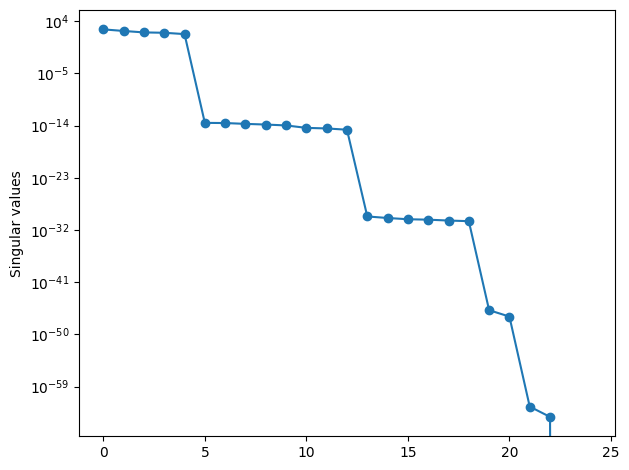

In [6]:
# Singular values
plt.figure()
plt.semilogy(s,'o-')
plt.ylabel('Singular values')
plt.tight_layout()
plt.show()

/var/folders/w5/_wg8zp6151qgmdqjbkqpfz3c0000gn/T/ipykernel_70442/3713746441.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  view_multiconfig_vibronic_coupling(matr, frequency=freq, coupling=coup).show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

/var/folders/w5/_wg8zp6151qgmdqjbkqpfz3c0000gn/T/ipykernel_70442/3713746441.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  view_multiconfig_vibronic_coupling(matr, frequency=freq, coupling=coup).show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

/var/folders/w5/_wg8zp6151qgmdqjbkqpfz3c0000gn/T/ipykernel_70442/3713746441.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  view_multiconfig_vibronic_coupling(matr, frequency=freq, coupling=coup).show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

/var/folders/w5/_wg8zp6151qgmdqjbkqpfz3c0000gn/T/ipykernel_70442/3713746441.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  view_multiconfig_vibronic_coupling(matr, frequency=freq, coupling=coup).show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

/var/folders/w5/_wg8zp6151qgmdqjbkqpfz3c0000gn/T/ipykernel_70442/3713746441.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  view_multiconfig_vibronic_coupling(matr, frequency=freq, coupling=coup).show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

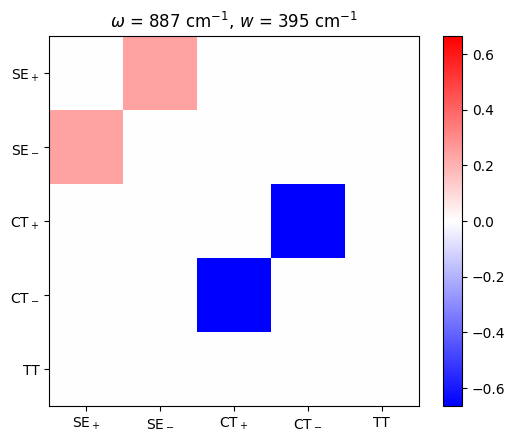

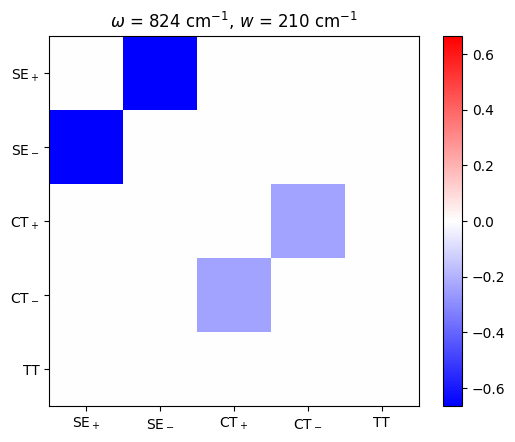

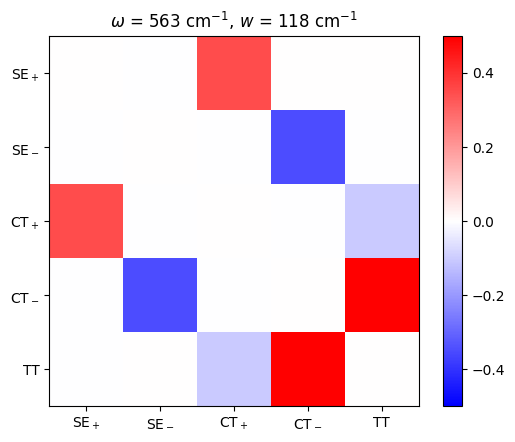

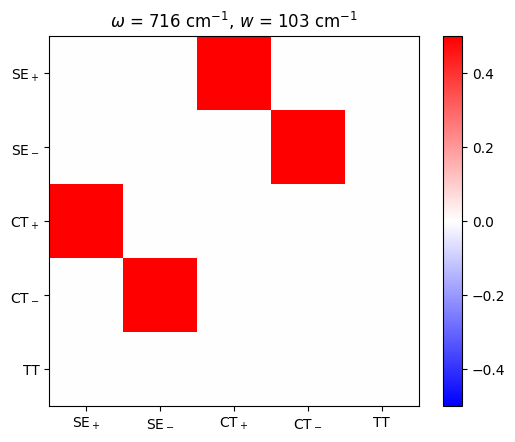

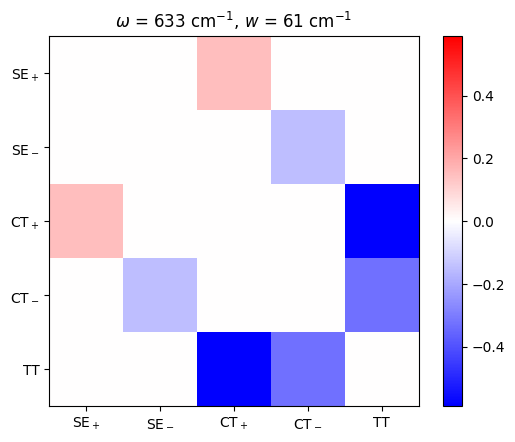

In [7]:
for i in range(5):
    matr = lvc_svd[i]
    freq, coup = omega_svd[i], s[i]
    vec = modevec_svd[:,i]
    view_multiconfig_vibronic_coupling(matr, frequency=freq, coupling=coup).show()
    view_vibration_animation(mol, vec, amplitude=.8, period=1000, fps=60).show()
    #view_vibration_arrows(mol, vec, amplitude=5., threshold=0.5).show()

## Exchange coupling spectral density
Triplet-triplet exchange coupling is proportional to $\sqrt{3} t^2_{h_\mathrm{A}l_\mathrm{B}}$.
Since $t^2_{h_\mathrm{A}l_\mathrm{B}} \approx 0$ at the equilibrium geometry due to symmetry, the vibronic coupling is just proportional to the gradient $2\sqrt{3}\partial_k t_{h_\mathrm{A}l_\mathrm{B}}$.
The resulting spectral density can be calculated as follows:

## Idea:
### We already have the vibronic coupling in the full MO basis - let's use it

Instead of doing SVD to identify the vibronic coupling patterns in a small pre-selected electroinc state manifold, we could use the information from more than those four frontier molecular orbitals?

This is the same as identifying a preferred vibronic basis?
Identify hieararchies with SVD.

### Clustering

Identify significant mode coupling patterns doing K-means clustering on the e-ph coupling matrix.

[Schroder et al. (2019) https://doi.org/10.1038/s41467-019-09039-7]

In [ ]:
data = vectorize_ephmat(lvc, normalize=True)
kmeans = cluster_ephmat(data, n_clusters=10, plot=True)

The cells below contain a lot of code that could just be transferred to the utility modules ```visutils``` and ```ephutils```.

In [ ]:
# Run clustering for different number of clusters and plot inertia
ks = list(range(2,19))
inertia = []
for k in ks:
    kmeans = cluster_ephmat(data, n_clusters=k, plot=False)
    inertia += [kmeans.inertia_]
plt.figure()
plt.semilogy(ks, inertia, "ko-")
plt.xticks(ks)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia (arb. units)")
plt.tight_layout()
plt.show()


In [ ]:
# Find mode clusters
nc = 10
data = vectorize_ephmat(lvc, normalize=True)
kmeans = cluster_ephmat(data, n_clusters=nc, plot=False)
indices = cluster_indices(kmeans.labels_)
# Plot spectral density
hwhm, wmax = 5, 1000
fgrid = np.linspace(1,wmax,int(wmax))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, nc))
yshift = 2000
plt.figure()
for n in range(nc):
    # find indices of modes belonging to current cluster
    idx = indices[n]
    x, y, z = omega[idx], lvc[idx], hwhm
    jgrid = effective_spectral_density(fgrid, x, y, z, plot=False) + yshift * n
    plt.plot(fgrid, jgrid, '-', color=colors[n])
# total effective spectral density
jtot = effective_spectral_density(fgrid, omega, lvc, plot=False)
jtot = jtot + yshift * nc
plt.plot(fgrid, jtot, "k-", linewidth=2)
plt.xlabel(r"Frequency / cm$^{-1}$")
plt.ylabel(r"Spectral Density / cm$^{-1}$")
plt.tight_layout()
plt.show()


In [ ]:
# --- reaction coordinate of each cluster (frequency, coupling) ---
nc = 10
data = vectorize_ephmat(lvc, normalize=True)
kmeans = cluster_ephmat(data, n_clusters=nc, plot=False)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
nc = centroids.shape[0]
centroids = centroids.reshape(nc, 5, 5)

cluster_freq, cluster_coup = [], []
centroid_freq, centroid_coup = [], []
centroid_sd = []

for cluster_label in range(nc):

    # normalise cluster centroid
    wc = centroids[cluster_label]
    wc_norm = np.linalg.norm(wc)
    wc = wc / wc_norm

    # rescale cluster elements
    w_cluster = lvc[labels==cluster_label] * wc_norm

    # cluster couplings and frequencies
    w_coup = np.linalg.norm(w_cluster, axis=(1,2))
    w_freq = omega[labels==cluster_label]
    
    # reaction coordinate coupling and frequency
    rc_coup = np.sqrt(np.sum(w_coup**2))
    rc_freq = np.sum(w_freq * w_coup**2) / rc_coup**2

    # store results
    cluster_coup += [w_coup]
    cluster_freq += [w_freq]
    centroid_coup += [rc_coup]
    centroid_freq += [rc_freq]
    #centroid_sd += [rc_sd]

print("Cluster RC frequency, coupling (cm^-1) ")
print(np.array([centroid_freq, centroid_coup]).T)
